# EDA del dataset procesado

Notebook de exploración del parquet generado por `src/preprocesado.py`.

**Objetivo:** ver cómo ha quedado el dataset listo para entrenar y detectar cualquier patrón raro, valor atípico, distribución desbalanceada o señal débil que convenga arreglar **antes** de meter el modelo.

Estructura:
- §1. Carga y vista general
- §2. Calidad de datos (missings, dtypes, sanity)
- §3. Distribución del target (pasajeros)
- §4. Distribución de features numéricas
- §5. Distribución de features categóricas
- §6. Correlaciones con el target
- §7. Patrones temporales y comparativas
- §8. Outliers y casos raros
- §9. Conclusiones — rellenar antes de modelar

## 0. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

pd.set_option('display.max_columns', 60)
pd.set_option('display.width', 200)
plt.rcParams['figure.figsize'] = (12, 5)

RAIZ = Path.cwd()
if RAIZ.name == 'notebooks':
    RAIZ = RAIZ.parent
RUTA_PARQUET = RAIZ / 'data' / 'processed' / 'numbat_long.parquet'
print(f'Parquet esperado en: {RUTA_PARQUET}')
print(f'¿Existe? {RUTA_PARQUET.exists()}')
if RUTA_PARQUET.exists():
    tam_mb = RUTA_PARQUET.stat().st_size / 1_000_000
    print(f'Tamaño: {tam_mb:.1f} MB')

Parquet esperado en: c:\Users\juan_\Desktop\Proyecto_p\Proyecto_productivizacion\data\processed\numbat_long.parquet
¿Existe? True
Tamaño: 3.5 MB


## 1. Carga del parquet y vista general

In [2]:
df = pd.read_parquet(RUTA_PARQUET)
print(f'Forma: {df.shape}')
print(f'Filas:    {len(df):,}')
print(f'Columnas: {len(df.columns)}')
print(f'Memoria:  {df.memory_usage(deep=True).sum() / 1_000_000:.1f} MB en RAM')
df.head(10)

Forma: (414720, 23)
Filas:    414,720
Columnas: 23
Memoria:  237.6 MB en RAM


,NLC,ASC,station_name_numbat,fare_zone_str,quarter_hour_slot,passengers,year,day_type,UniqueStationName,InnerFareZone,OuterFareZone,FullyGated,Hub,Active,TfL,Latitude,Longitude,num_lines,num_modes,hour,minute,is_peak,is_night
0,750,ABRd,Abbey Road,2/3,0500-0515,4.072246,2023,MON,Abbey Road,2,3,No,ABRd,True,True,51.532539,0.003605,1,1,5,0,False,False
1,1404,ACCr,Acton Central,3,0500-0515,0.000000,2023,MON,Acton Central,3,3,Yes,ACCr,True,True,51.508712,-0.262812,1,0,5,0,False,False
2,3000,AMLr,Acton Main Line,3,0500-0515,15.935178,2023,MON,Acton Main Line,3,3,2019,AMLr,True,True,51.516971,-0.267946,1,0,5,0,False,False
3,500,ACTu,Acton Town,3,0500-0515,11.645179,2023,MON,Acton Town,3,3,Yes,ACTu,True,True,51.502706,-0.279971,2,1,5,0,False,False
4,502,ALDu,Aldgate,1,0500-0515,5.544855,2023,MON,Aldgate,1,1,Yes,ALDu,True,True,51.514245,-0.075717,2,1,5,0,False,False
5,503,ALEu,Aldgate East,1,0500-0515,6.465746,2023,MON,Aldgate East,1,1,Yes,ALEu,True,True,51.515622,-0.070846,2,1,5,0,False,False
6,850,ALSd,All Saints,2,0500-0515,2.096622,2023,MON,All Saints,2,2,No,ALSd,True,True,51.510564,-0.013010,1,1,5,0,False,False
7,505,ALPu,Alperton,4,0500-0515,12.583561,2023,MON,Alperton,4,4,Yes,ALPu,True,True,51.540804,-0.300093,1,1,5,0,False,False
8,506,AMEu,Amersham,9,0500-0515,14.879002,2023,MON,Amersham,9,9,Yes,AMEu,True,True,51.674085,-0.607368,1,1,5,0,False,False
9,5397,ANYr,Anerley,4,0500-0515,22.234245,2023,MON,Anerley,4,4,No,ANYr,True,True,51.412587,-0.065580,1,0,5,0,False,False


In [3]:
# Dtypes
df.dtypes.sort_values()

is_night                  bool
TfL                       bool
Active                    bool
is_peak                   bool
minute                    int8
hour                      int8
year                     int16
NLC                      int32
InnerFareZone            int64
OuterFareZone            int64
num_lines                int64
num_modes                int64
passengers             float64
Latitude               float64
Longitude              float64
UniqueStationName       object
Hub                     object
quarter_hour_slot       object
fare_zone_str           object
station_name_numbat     object
ASC                     object
day_type                object
FullyGated              object
dtype: object

In [4]:
# Conteo de combinaciones (year, day_type): deberian ser equilibradas
print('Filas por (year, day_type) — deberian ser todas iguales:')
print(df.groupby(['year', 'day_type'], observed=True).size().unstack())

Filas por (year, day_type) — deberian ser todas iguales:
day_type    FRI    MON    SAT    SUN    TWT
year                                       
2023      41472  41472  41472  41472  41472
2024      41472  41472  41472  41472  41472


## 2. Calidad de datos: missings, dtypes y consistencia

In [5]:
# Conteo de NaN por columna
missings = df.isna().sum().sort_values(ascending=False)
missings = missings[missings > 0]
if len(missings) > 0:
    print(f'Columnas con NaN ({len(missings)}):')
    print(missings)
else:
    print('Sin NaN explícitos en ninguna columna. OK.')

Sin NaN explícitos en ninguna columna. OK.


In [6]:
# Ceros: distribucion de pasajeros = 0 (estructurales + bajo trafico)
n_ceros = (df['passengers'] == 0).sum()
print(f'Filas con passengers = 0: {n_ceros:,} ({n_ceros/len(df)*100:.1f}%)')
print(f'  De esos, en horario nocturno (is_night): {((df["passengers"]==0) & df["is_night"]).sum():,}')
print(f'  De esos, en horario diurno (no is_night): {((df["passengers"]==0) & ~df["is_night"]).sum():,}')

Filas con passengers = 0: 54,675 (13.2%)
  De esos, en horario nocturno (is_night): 51,392
  De esos, en horario diurno (no is_night): 3,283


In [7]:
# Conteo de estaciones unicas por modo TfL (num_modes flag)
estaciones = df.drop_duplicates('NLC')
print(f'Estaciones unicas: {len(estaciones)}')
print(f'\nEstaciones por num_modes (flag TfL rail):')
print(estaciones['num_modes'].value_counts().sort_index())
print(f'\nEstaciones por num_lines (lineas TfL rail):')
print(estaciones['num_lines'].value_counts().sort_index())

Estaciones unicas: 432

Estaciones por num_modes (flag TfL rail):
num_modes
0    121
1    307
2      4
Name: count, dtype: int64

Estaciones por num_lines (lineas TfL rail):
num_lines
1    335
2     71
3     16
4      7
5      2
6      1
Name: count, dtype: int64


## 3. Distribución del target (`passengers`)

In [8]:
print('Estadisticas del target:')
print(df['passengers'].describe().round(2))
print(f'\nValores extremos:')
print(f'  Maximo: {df["passengers"].max():.0f}')
print(f'  P95:    {df["passengers"].quantile(0.95):.0f}')
print(f'  P99:    {df["passengers"].quantile(0.99):.0f}')
print(f'  P99.9:  {df["passengers"].quantile(0.999):.0f}')

Estadisticas del target:
count    414720.00
mean        101.99
std         220.18
min           0.00
25%           6.92
50%          38.75
75%         102.56
max        5961.44
Name: passengers, dtype: float64

Valores extremos:
  Maximo: 5961
  P95:    392
  P99:    1146
  P99.9:  2386


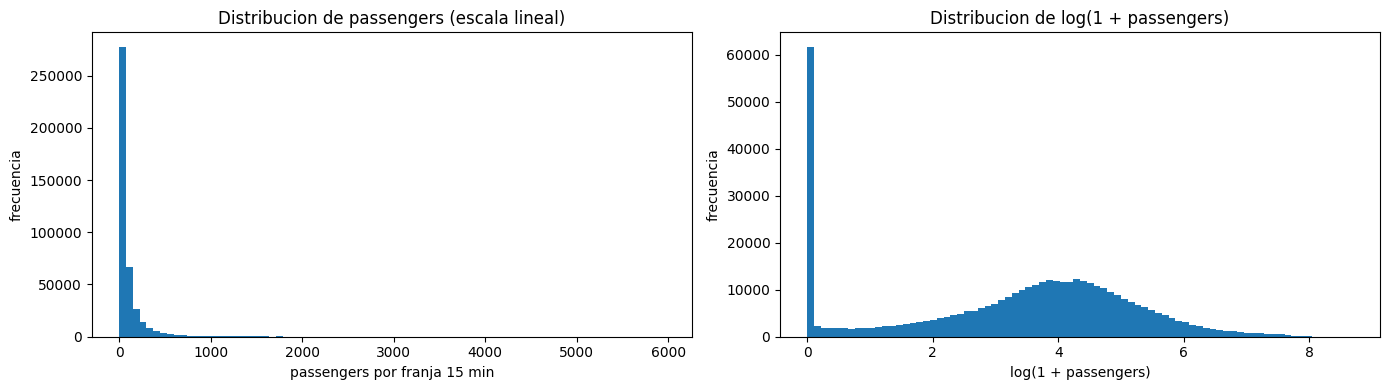

In [9]:
# Histograma del target (escala lineal y log)
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].hist(df['passengers'], bins=80)
axes[0].set_title('Distribucion de passengers (escala lineal)')
axes[0].set_xlabel('passengers por franja 15 min')
axes[0].set_ylabel('frecuencia')

# Log: solo valores > 0
axes[1].hist(np.log1p(df['passengers']), bins=80)
axes[1].set_title('Distribucion de log(1 + passengers)')
axes[1].set_xlabel('log(1 + passengers)')
axes[1].set_ylabel('frecuencia')
plt.tight_layout()
plt.show()

**Qué mirar aquí:**
- ¿La distribución es muy sesgada a la derecha (cola larga)? Es lo esperable, pero confirma si conviene transformar el target con `log1p` para el modelo.
- ¿Hay pico anormal en cero por estaciones nocturnas?
- ¿El máximo es un outlier puntual o varias estaciones llegan a esos valores?

## 4. Distribución de features numéricas

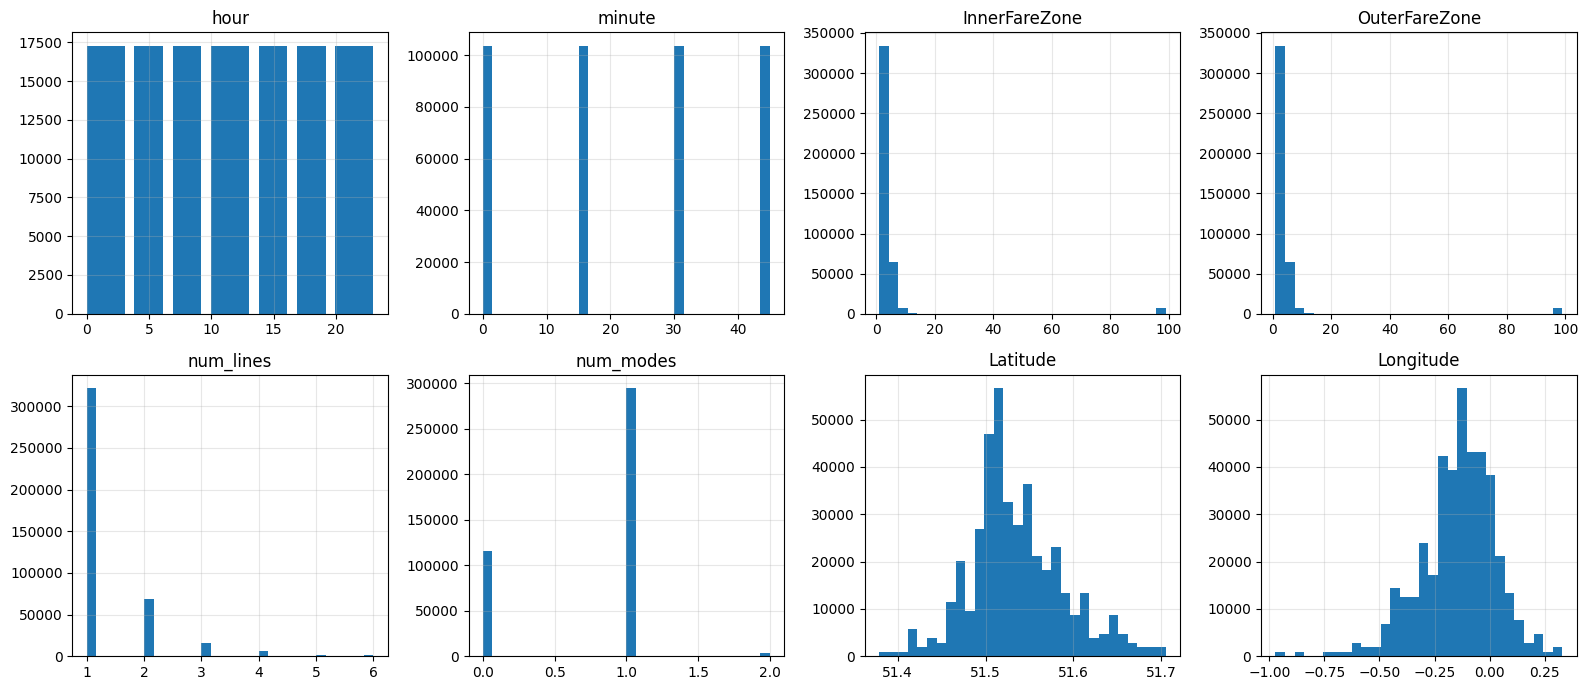

In [10]:
cols_num = ['hour', 'minute', 'InnerFareZone', 'OuterFareZone',
            'num_lines', 'num_modes', 'Latitude', 'Longitude']
cols_num = [c for c in cols_num if c in df.columns]

fig, axes = plt.subplots(2, 4, figsize=(16, 7))
for ax, col in zip(axes.flat, cols_num):
    df[col].hist(bins=30, ax=ax)
    ax.set_title(col)
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

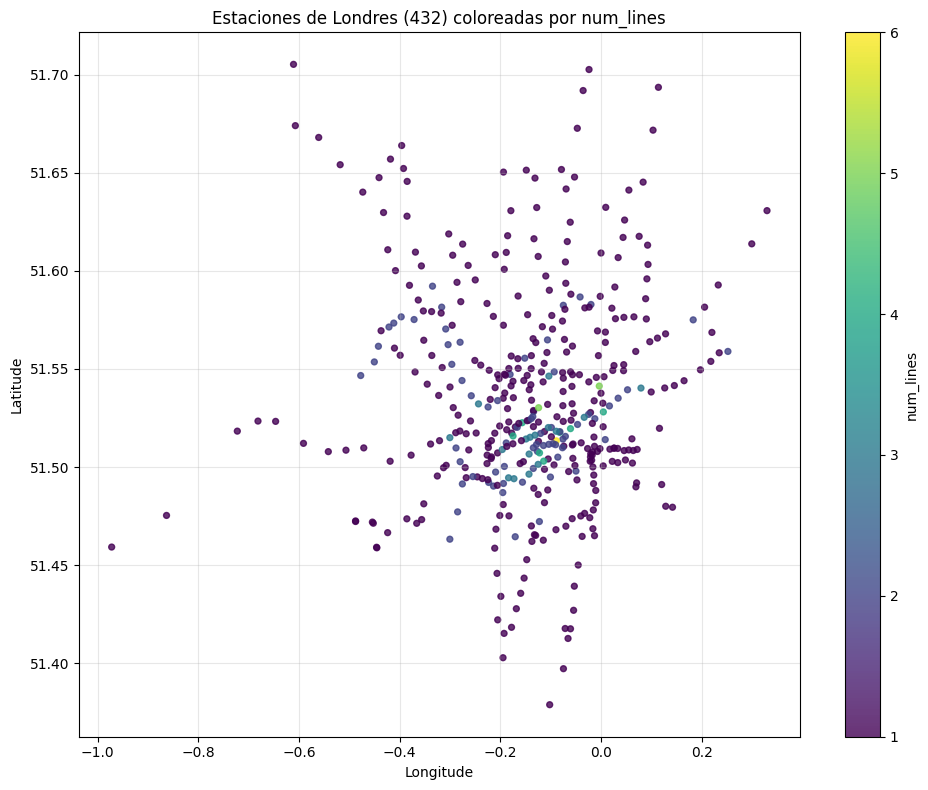

In [11]:
# Mapa rapido lat/lon: solo estaciones unicas, colorado por num_lines
est = df.drop_duplicates('NLC').dropna(subset=['Latitude', 'Longitude'])
fig, ax = plt.subplots(figsize=(10, 8))
sc = ax.scatter(est['Longitude'], est['Latitude'], c=est['num_lines'],
                cmap='viridis', s=18, alpha=0.8)
plt.colorbar(sc, ax=ax, label='num_lines')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title(f'Estaciones de Londres ({len(est)}) coloreadas por num_lines')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 5. Distribución de features categóricas

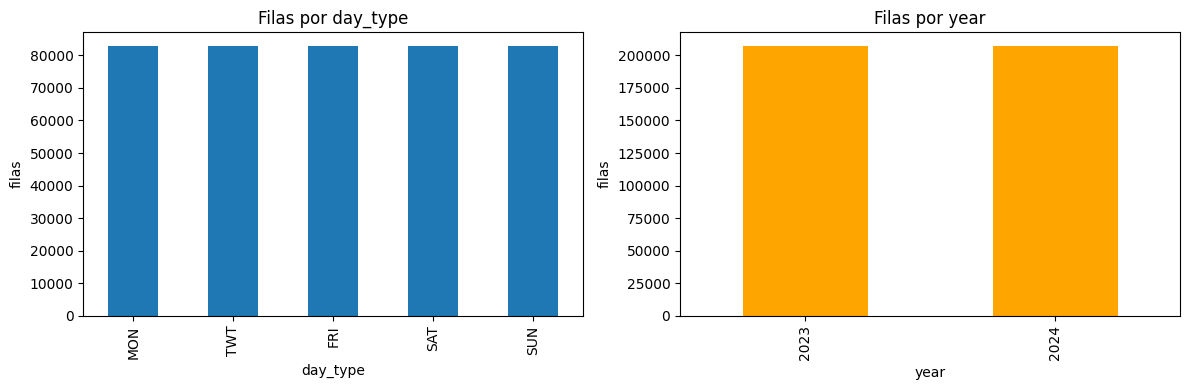

In [12]:
# day_type y year son las categoricas explicitas
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df['day_type'].value_counts().reindex(['MON','TWT','FRI','SAT','SUN']).plot.bar(ax=axes[0])
axes[0].set_title('Filas por day_type')
axes[0].set_ylabel('filas')
df['year'].value_counts().sort_index().plot.bar(ax=axes[1], color='orange')
axes[1].set_title('Filas por year')
axes[1].set_ylabel('filas')
plt.tight_layout()
plt.show()

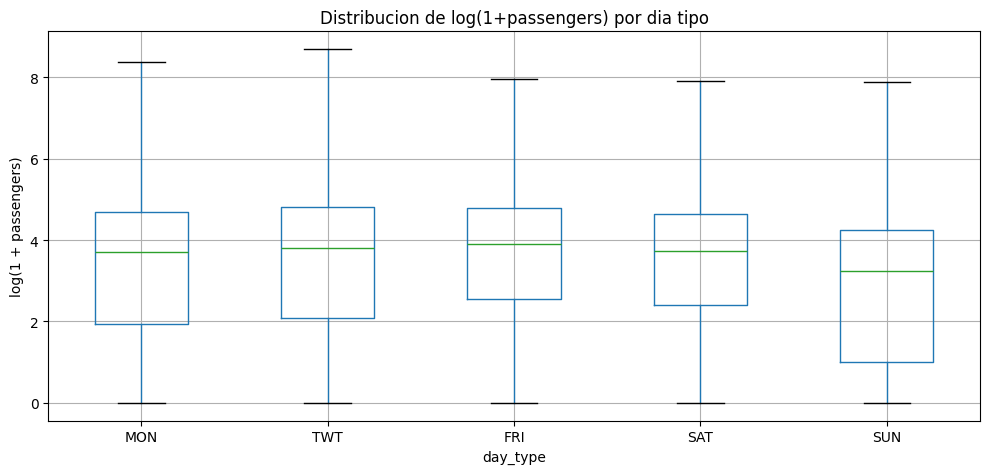

In [13]:
# Distribucion del target POR day_type (boxplot, escala log)
# Forzamos orden de dias con pd.Categorical (pandas.boxplot no acepta 'order').
orden = ['MON', 'TWT', 'FRI', 'SAT', 'SUN']
df_tmp = df.assign(
    log_pass=np.log1p(df['passengers']),
    day_type_ord=pd.Categorical(df['day_type'], categories=orden, ordered=True)
)
fig, ax = plt.subplots(figsize=(10, 5))
df_tmp.boxplot(column='log_pass', by='day_type_ord', ax=ax)
ax.set_title('Distribucion de log(1+passengers) por dia tipo')
plt.suptitle('')
ax.set_ylabel('log(1 + passengers)')
ax.set_xlabel('day_type')
plt.tight_layout()
plt.show()

## 6. Correlaciones con el target

In [14]:
# Correlacion Pearson de numericas con passengers
cols_corr = ['passengers', 'hour', 'minute', 'InnerFareZone', 'OuterFareZone',
             'num_lines', 'num_modes', 'Latitude', 'Longitude',
             'is_peak', 'is_night', 'year']
cols_corr = [c for c in cols_corr if c in df.columns]
corr = df[cols_corr].corr()['passengers'].sort_values(ascending=False)
print('Correlacion Pearson con passengers:')
print(corr.round(3))

Correlacion Pearson con passengers:
passengers       1.000
num_lines        0.456
is_peak          0.207
hour             0.163
num_modes        0.141
Longitude        0.047
year             0.005
minute           0.001
OuterFareZone   -0.064
InnerFareZone   -0.064
Latitude        -0.132
is_night        -0.225
Name: passengers, dtype: float64


**Qué mirar aquí:**
- Correlaciones fuertes esperadas: `num_lines` (más líneas → más tráfico), `is_peak` (hora punta → más), `is_night` (negativa, noche → menos).
- Si alguna correlación sorprende mucho (p. ej. `Latitude` muy alta), puede revelar un patrón espacial fuerte (centro vs periferia).
- Pearson capta sólo lineales — el modelo XGBoost sí captará no-lineales, así que correlaciones bajas no descartan utilidad.

## 7. Patrones temporales y comparativas

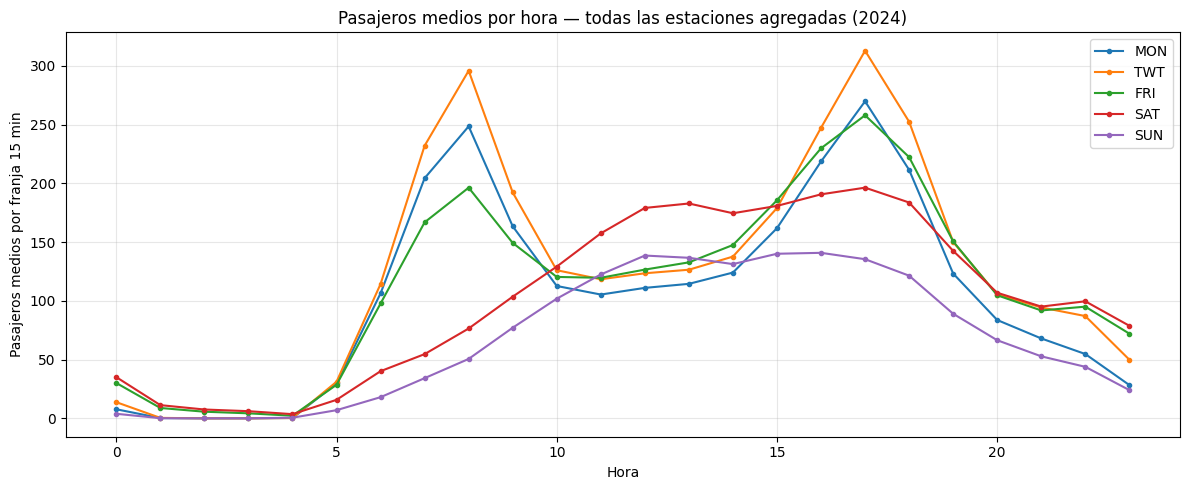

In [15]:
# Patron diario promedio: pasajeros por hora, por tipo de dia (2024)
df24 = df[df['year'] == 2024]
perfil = df24.groupby(['day_type', 'hour'], observed=True)['passengers'].mean().unstack(0)
fig, ax = plt.subplots(figsize=(12, 5))
for dia in ['MON', 'TWT', 'FRI', 'SAT', 'SUN']:
    if dia in perfil.columns:
        ax.plot(perfil.index, perfil[dia], label=dia, marker='o', markersize=3)
ax.set_title('Pasajeros medios por hora — todas las estaciones agregadas (2024)')
ax.set_xlabel('Hora')
ax.set_ylabel('Pasajeros medios por franja 15 min')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

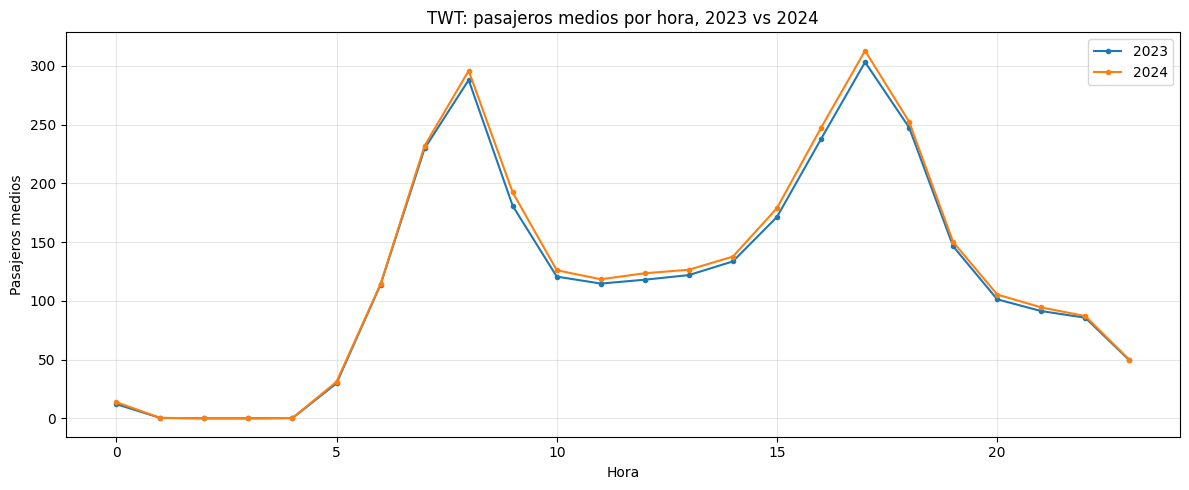

In [16]:
# Patron 2023 vs 2024 (mismo dia tipo TWT)
perfil_anios = df[df['day_type'] == 'TWT'].groupby(['year', 'hour'], observed=True)['passengers'].mean().unstack(0)
fig, ax = plt.subplots(figsize=(12, 5))
for anio in perfil_anios.columns:
    ax.plot(perfil_anios.index, perfil_anios[anio], label=str(anio), marker='o', markersize=3)
ax.set_title('TWT: pasajeros medios por hora, 2023 vs 2024')
ax.set_xlabel('Hora')
ax.set_ylabel('Pasajeros medios')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**Qué mirar aquí:**
- 2023 vs 2024: ¿son muy parecidos (entonces tendría sentido pool 2023+24 y random split) o hay drift visible (entonces el split temporal train=2023, test=2024 es más informativo)?
- Confirmar visualmente que MON ≠ TWT (justifica el 5-day-types) y que FRI tiene cola larga de noche.

## 8. Outliers y casos raros

In [17]:
# Top 20 valores de passengers en todo el dataset
top20 = df.nlargest(20, 'passengers')[
    ['UniqueStationName', 'year', 'day_type', 'quarter_hour_slot', 'passengers']
]
print('Top 20 filas con mas pasajeros en una franja de 15 min:')
print(top20.to_string(index=False))

Top 20 filas con mas pasajeros en una franja de 15 min:
  UniqueStationName  year day_type quarter_hour_slot  passengers
        Waterloo LU  2024      TWT         0830-0845 5961.444076
        Waterloo LU  2024      TWT         0815-0830 5925.875200
        Waterloo LU  2023      TWT         0830-0845 5852.445479
        Waterloo LU  2023      TWT         0815-0830 5730.770882
        Waterloo LU  2024      TWT         0800-0815 5594.037033
        Waterloo LU  2023      TWT         0800-0815 5526.930168
        Waterloo LU  2024      TWT         0845-0900 5378.744913
        Waterloo LU  2023      TWT         0845-0900 5081.619668
Liverpool Street LU  2024      TWT         1730-1745 5004.728615
        Waterloo LU  2023      TWT         0745-0800 4965.456480
Liverpool Street LU  2024      TWT         1745-1800 4921.444200
        Waterloo LU  2024      TWT         0745-0800 4918.127580
        Waterloo LU  2024      TWT         0900-0915 4732.896610
Liverpool Street LU  2024      TWT

In [18]:
# Estaciones con MAYOR volumen diario medio
vol_diario = df.groupby('UniqueStationName', observed=True)['passengers'].sum().sort_values(ascending=False)
print('Top 15 estaciones por volumen total:')
print(vol_diario.head(15).round(0).astype(int))
print('\nBottom 15 (estaciones con menos trafico):')
print(vol_diario.tail(15).round(0).astype(int))

Top 15 estaciones por volumen total:
UniqueStationName
King's Cross St. Pancras    1089369
Waterloo LU                 1007635
Victoria LU                  862413
Tottenham Court Road         857398
London Bridge LU             830318
Stratford                    808996
Liverpool Street LU          807779
Paddington TfL               754753
Oxford Circus                706188
Bond Street                  555609
Farringdon                   535805
Bank and Monument            476812
Euston LU                    454349
Leicester Square             442776
Canary Wharf LU              435124
Name: passengers, dtype: int32

Bottom 15 (estaciones con menos trafico):
UniqueStationName
Moor Park            11095
Taplow               11007
Upminster Bridge     10709
Theydon Bois         10555
Hatch End            10306
Kilburn High Road    10074
North Ealing          8935
South Hampstead       8163
Headstone Lane        7942
Beckton Park          7885
Iver                  7146
Emerson Park    

In [19]:
# Estaciones con num_modes = 0 (las que decian que solo tienen flag de NR)
sin_modo_tfl = df[df['num_modes'] == 0].drop_duplicates('NLC')
print(f'Estaciones con num_modes == 0: {len(sin_modo_tfl)}')
print('  (son las que solo tienen flag de National Rail, no TfL rail mode).')
print('  Ejemplos:')
print(sin_modo_tfl[['UniqueStationName', 'InnerFareZone', 'num_lines']].head(15).to_string(index=False))

Estaciones con num_modes == 0: 121
  (son las que solo tienen flag de National Rail, no TfL rail mode).
  Ejemplos:
          UniqueStationName  InnerFareZone  num_lines
              Acton Central              3          1
            Acton Main Line              3          1
                    Anerley              4          1
          Barking Riverside              4          1
           Bethnal Green LO              2          1
                  Brentwood              9          1
                   Brockley              2          1
                Brondesbury              2          1
           Brondesbury Park              2          1
                Bruce Grove              3          1
                    Burnham             99          1
             Bush Hill Park              5          1
                     Bushey              8          1
Caledonian Road & Barnsbury              2          1
            Cambridge Heath              2          1


**Qué decidir aquí:** ¿usamos las estaciones con `num_modes == 0` en el entrenamiento o las filtramos? Argumentos a favor de mantenerlas: NUMBAT *sí* mide estos pasajeros (no son ceros), y son estaciones reales. En contra: la feature `num_modes` no las describe bien (siempre 0).

## 9. Conclusiones — rellenar antes de modelar

**9.1. Calidad de datos**
- ¿Hay NaN que arreglar? …
- ¿Algún tipo de dato sorprendente? …

**9.2. Sobre el target**
- ¿La cola larga sugiere usar `log1p(passengers)` como target? …
- ¿Los outliers del top 20 son creíbles o sospechosos? …

**9.3. Sobre las features**
- Correlaciones esperadas confirmadas: …
- Correlaciones inesperadas: …
- Decisión sobre `num_modes == 0`: incluir / excluir / añadir nueva feature `tiene_NR`: …

**9.4. Sobre el split**
- ¿2023 y 2024 son lo bastante parecidos para split aleatorio, o mejor temporal? …

**9.5. Cosas que me han sorprendido**
- …